#**Predicting NBA shots**




#1. faza: Priprema i vizualizacija podataka
---

In [61]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### ***Priprema podataka***

***Učitavanje podataka***

In [62]:
import numpy as np
import pandas as pd
shot_logs = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/shot_logs.csv")

***Početni pregled podataka***

In [63]:
print("Broj primjera u datasetu: ", shot_logs.shape[0])
print("Broj atributa u datasetu: ", shot_logs.shape[1])

print("Atributi u datasetu: ")
for i in range(shot_logs.columns.size):
  print(shot_logs.columns[i])

Broj primjera u datasetu:  128069
Broj atributa u datasetu:  21
Atributi u datasetu: 
GAME_ID
MATCHUP
LOCATION
W
FINAL_MARGIN
SHOT_NUMBER
PERIOD
GAME_CLOCK
SHOT_CLOCK
DRIBBLES
TOUCH_TIME
SHOT_DIST
PTS_TYPE
SHOT_RESULT
CLOSEST_DEFENDER
CLOSEST_DEFENDER_PLAYER_ID
CLOSE_DEF_DIST
FGM
PTS
player_name
player_id


Provjeravamo tipove podataka

In [64]:
print(shot_logs.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

***Detekcija monotonih atributa***

In [65]:
print("Broj jedinstvenih vrijednosti po stupcima: ")
print(shot_logs.nunique())

Broj jedinstvenih vrijednosti po stupcima: 
GAME_ID                        904
MATCHUP                       1808
LOCATION                         2
W                                2
FINAL_MARGIN                    88
SHOT_NUMBER                     38
PERIOD                           7
GAME_CLOCK                     719
SHOT_CLOCK                     241
DRIBBLES                        33
TOUCH_TIME                     313
SHOT_DIST                      448
PTS_TYPE                         2
SHOT_RESULT                      2
CLOSEST_DEFENDER               473
CLOSEST_DEFENDER_PLAYER_ID     474
CLOSE_DEF_DIST                 299
FGM                              2
PTS                              3
player_name                    281
player_id                      281
dtype: int64


***Detekcija nedostajućih vrijednosti***

In [66]:
for i in range(shot_logs.columns.size):
  if shot_logs[shot_logs.columns[i]].isna().values.any():
    print("Stupac " + shot_logs.columns[i] + " ima nedostajuće vrijednosti.")

Stupac SHOT_CLOCK ima nedostajuće vrijednosti.


Zamjenjujemo nedostajuće vrijednosti atributa SHOT_CLOCK s vrijednostima atributa GAME_CLOCK.

In [67]:
import math

def convert_time(x):
  return float(x.split(":")[0]) * 60 + float(x.split(":")[1])

for i in range(shot_logs.shape[0]):
  shot_logs["GAME_CLOCK"][i] = convert_time(shot_logs["GAME_CLOCK"][i])
  if (math.isnan(float(shot_logs["SHOT_CLOCK"][i]))):
    if (shot_logs["GAME_CLOCK"][i] <= 24.0):
      shot_logs["SHOT_CLOCK"][i] = shot_logs["GAME_CLOCK"][i]
    else:
      shot_logs["SHOT_CLOCK"][i] = 0.0

shot_logs["GAME_CLOCK"] = shot_logs["GAME_CLOCK"].astype(float)
print(shot_logs.isna().any())

<ipython-input-67-7f310760ff9c>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shot_logs["GAME_CLOCK"][i] = convert_time(shot_logs["GAME_CLOCK"][i])
<ipython-input-67-7f310760ff9c>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shot_logs["SHOT_CLOCK"][i] = shot_logs["GAME_CLOCK"][i]
<ipython-input-67-7f310760ff9c>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  shot_logs["SHOT_CLOCK"][i] = 0.0


GAME_ID                       False
MATCHUP                       False
LOCATION                      False
W                             False
FINAL_MARGIN                  False
SHOT_NUMBER                   False
PERIOD                        False
GAME_CLOCK                    False
SHOT_CLOCK                    False
DRIBBLES                      False
TOUCH_TIME                    False
SHOT_DIST                     False
PTS_TYPE                      False
SHOT_RESULT                   False
CLOSEST_DEFENDER              False
CLOSEST_DEFENDER_PLAYER_ID    False
CLOSE_DEF_DIST                False
FGM                           False
PTS                           False
player_name                   False
player_id                     False
dtype: bool


In [68]:
shot_logs.describe()

,GAME_ID,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_id
count,1.280690e+05,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000,128069.000000
mean,2.140045e+07,0.208723,6.506899,2.469427,351.393811,12.030230,2.023355,2.765901,13.571504,2.264670,159038.487284,4.123015,0.452139,0.997314,157238.251247
std,2.578773e+02,13.233267,4.713260,1.139919,207.590603,6.048763,3.477760,3.043682,8.888964,0.441159,78791.172947,2.756446,0.497706,1.130978,79362.389336
min,2.140000e+07,-53.000000,1.000000,1.000000,0.000000,0.000000,0.000000,-163.600000,0.000000,2.000000,708.000000,0.000000,0.000000,0.000000,708.000000
25%,2.140023e+07,-8.000000,3.000000,1.000000,172.000000,7.600000,0.000000,0.900000,4.700000,2.000000,101249.000000,2.300000,0.000000,0.000000,101162.000000
50%,2.140045e+07,1.000000,5.000000,2.000000,352.000000,12.000000,1.000000,1.600000,13.700000,2.000000,201949.000000,3.700000,0.000000,0.000000,201939.000000
75%,2.140067e+07,9.000000,9.000000,3.000000,531.000000,16.400000,2.000000,3.700000,22.500000,3.000000,203079.000000,5.300000,1.000000,2.000000,202704.000000
max,2.140091e+07,53.000000,38.000000,7.000000,720.000000,24.000000,32.000000,24.900000,47.200000,3.000000,530027.000000,53.200000,1.000000,3.000000,204060.000000


Uočavamo postojanje postojanje negativnih vrijednosti za atribute FINAL_MARGIN i TOUCH_TIME. Atribut FINAL_MARGIN ima smisla bit negativan dok atribut TOUCH_TIME nikako ne bi smio poprimat negativne vrijednosti.

In [69]:
shot_logs[shot_logs.TOUCH_TIME < 0]

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
748,21400625,"JAN 21, 2015 - CHA vs. MIA",H,W,2,7,4,475.0,9.0,0,...,7.5,2,made,"Napier, Shabazz",203894,3.9,1,2,al jefferson,2744
775,21400459,"DEC 29, 2014 - CHA vs. MIL",H,L,-10,12,4,454.0,6.3,0,...,4.1,2,missed,"Henson, John",203089,0.1,0,0,al jefferson,2744
1043,21400195,"NOV 23, 2014 - CHA @ MIA",A,L,-1,17,4,2.0,2.0,0,...,1.3,2,missed,"Williams, Shawne",200761,1.3,0,0,al jefferson,2744
1118,21400130,"NOV 14, 2014 - CHA @ PHX",A,W,8,7,2,336.0,17.7,0,...,5.0,2,made,"Plumlee, Miles",203101,3.7,1,2,al jefferson,2744
1260,21400028,"NOV 01, 2014 - CHA vs. MEM",H,L,-2,9,3,660.0,23.7,0,...,8.4,2,missed,"Conley, Mike",201144,0.6,0,0,al jefferson,2744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124820,21400590,"JAN 16, 2015 - BKN @ WAS",A,W,22,10,3,571.0,16.8,0,...,1.9,2,missed,"Gortat, Marcin",101162,0.0,0,0,mason plumlee,203486
125018,21400266,"DEC 03, 2014 - BKN vs. SAS",H,W,2,3,4,498.0,19.5,0,...,3.8,2,missed,"Bonner, Matt",2588,1.0,0,0,mason plumlee,203486
125057,21400116,"NOV 12, 2014 - BKN @ PHX",A,L,-8,2,4,583.0,14.3,0,...,3.2,2,missed,"Morris, Marcus",202694,2.0,0,0,mason plumlee,203486
125059,21400090,"NOV 09, 2014 - BKN vs. ORL",H,W,8,2,2,680.0,21.6,0,...,3.4,2,missed,"Frye, Channing",101112,2.0,0,0,mason plumlee,203486


Izbacivanje redaka s negativnim vrijednostima atributa TOUCH_TIME.

In [70]:
shot_logs = shot_logs.loc[shot_logs[shot_logs.TOUCH_TIME.name] >= 0.0]

Uočavamo postojanje stršećih vrijednosti gdje postoje šutevi koji vrijede 2 poena, ali ih je igrač opucao na udaljenosti za 3 poena.

In [71]:
shot_logs[(shot_logs.PTS_TYPE == 2) & (shot_logs.SHOT_DIST > 23.75)]

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
888,21400355,"DEC 15, 2014 - CHA @ CLE",A,L,-9,13,4,17.0,17.0,0,...,27.9,2,made,"Marion, Shawn",1890,7.0,1,2,al jefferson,2744
1435,21400510,"JAN 05, 2015 - CHA @ BOS",A,W,9,6,2,167.0,19.7,0,...,24.9,2,made,"Zeller, Tyler",203092,9.2,1,2,cody zeller,203469
1741,21400713,"JAN 31, 2015 - CHA @ DEN",A,W,18,5,2,367.0,20.8,0,...,28.4,2,missed,"Afflalo, Arron",201167,10.0,0,0,gary neal,202390
1806,21400510,"JAN 05, 2015 - CHA @ BOS",A,W,9,7,2,368.0,13.2,4,...,24.5,2,missed,"Turner, Evan",202323,0.6,0,0,gary neal,202390
1940,21400334,"DEC 12, 2014 - CHA @ MEM",A,L,-6,1,1,125.0,19.9,7,...,25.6,2,missed,"Koufos, Kosta",201585,8.8,0,0,gary neal,202390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126356,21400759,"FEB 07, 2015 - BKN @ WAS",A,L,-37,6,2,391.0,0.5,0,...,24.3,2,missed,"Butler, Rasual",2446,5.5,0,0,joe johnson,2207
126419,21400683,"JAN 28, 2015 - BKN @ ATL",A,L,-11,14,3,245.0,18.0,6,...,23.9,2,missed,"Sefolosha, Thabo",200757,5.0,0,0,joe johnson,2207
126501,21400564,"JAN 12, 2015 - BKN vs. HOU",H,L,-14,3,2,318.0,10.1,0,...,23.8,2,made,"Ariza, Trevor",2772,8.9,1,2,joe johnson,2207
127235,21400539,"JAN 09, 2015 - BKN vs. PHI",H,L,-2,2,2,537.0,2.5,7,...,24.4,2,missed,"Wroten, Tony",203100,3.8,0,0,bojan bogdanovic,202711


Prepravljanje atributa PTS i PTS_TYPE s vrijednosti 2 u vrijednost 3 za sve  šuteve koji su opucani na udaljenosti za 3 poena.

In [72]:
mask = (shot_logs[shot_logs.PTS_TYPE.name] == 2) & (shot_logs[shot_logs.SHOT_DIST.name] > 23.75) & (shot_logs[shot_logs.PTS.name] == 0)
shot_logs.loc[mask, shot_logs.PTS_TYPE.name] = 3
shot_logs.loc[mask, shot_logs.PTS.name] = 0

mask = (shot_logs[shot_logs.PTS_TYPE.name] == 2) & (shot_logs[shot_logs.SHOT_DIST.name] > 23.75) & (shot_logs[shot_logs.PTS.name] != 0)
shot_logs.loc[mask, shot_logs.PTS_TYPE.name] = 3
shot_logs.loc[mask, shot_logs.PTS.name] = 3

shot_logs[(shot_logs.PTS_TYPE == 2) & (shot_logs.SHOT_DIST > 23.75)]

,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,...,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id


***Korištenje klase LabelEncoder za promjenu atributa W u numeričke vrijednosti***

In [73]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(shot_logs.loc[:,"W"])

shot_logs.loc[:,"W"] = le.transform(shot_logs.loc[:,"W"])

<ipython-input-73-cc70956b7c4b>:6: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  shot_logs.loc[:,"W"] = le.transform(shot_logs.loc[:,"W"])


***Korištenje klase LabelEncoder za promjenu atributa LOCATION u numeričke vrijednosti***

In [74]:
le = LabelEncoder()
le.fit(shot_logs.loc[:,"LOCATION"])

shot_logs.loc[:,"LOCATION"] = le.transform(shot_logs.loc[:,"LOCATION"])

<ipython-input-74-b59275562136>:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  shot_logs.loc[:,"LOCATION"] = le.transform(shot_logs.loc[:,"LOCATION"])


***Korištenje klase LabelEncoder za promjenu atributa SHOT_RESULT u numeričke vrijednosti***

In [75]:
le = LabelEncoder()
le.fit(shot_logs.loc[:,"SHOT_RESULT"])

shot_logs.loc[:,"SHOT_RESULT"] = le.transform(shot_logs.loc[:,"SHOT_RESULT"])

<ipython-input-75-067f36551968>:4: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  shot_logs.loc[:,"SHOT_RESULT"] = le.transform(shot_logs.loc[:,"SHOT_RESULT"])


***Izračun prosjeka i standardne devijacije vaŽanih podataka po utakmici za svakog igrača***

In [76]:
player = shot_logs.groupby([shot_logs.GAME_ID.name, shot_logs.MATCHUP.name, shot_logs.player_name.name]).agg(PTS=(shot_logs.PTS.name, np.sum), close_def_dist_total_pg=(shot_logs.CLOSE_DEF_DIST.name, np.sum), close_def_dist_mean_pg=(shot_logs.CLOSE_DEF_DIST.name, np.mean), close_def_dist_stdev_pg=(shot_logs.CLOSE_DEF_DIST.name, np.std), shot_dist_total_pg=(shot_logs.SHOT_DIST.name, np.sum), shot_dist_mean_pg=(shot_logs.SHOT_DIST.name, np.mean), shot_dist_stdev_pg=(shot_logs.SHOT_DIST.name, np.std), touch_time_total_pg=(shot_logs.TOUCH_TIME.name, np.sum), touch_time_mean_pg=(shot_logs.TOUCH_TIME.name, np.mean), touch_time_stdev_pg=(shot_logs.TOUCH_TIME.name, np.std), dribbles_total_pg=(shot_logs.DRIBBLES.name, np.sum), dribbles_mean_pg=(shot_logs.DRIBBLES.name, np.mean), dribbles_stdev_pg=(shot_logs.DRIBBLES.name, np.std))
player

PTS  \
GAME_ID  MATCHUP                    player_name              
21400001 OCT 28, 2014 - NOP vs. ORL alexis ajinca        2   
                                    anthony davis       20   
                                    jimmer dredette      0   
                                    jrue holiday         8   
                                    omer asik           14   
...                                                    ...   
21400908 MAR 04, 2015 - POR @ LAC   damian lillard       2   
                                    lamarcus aldridge   22   
                                    nicolas batum       16   
                                    steve blake          2   
                                    wesley matthews      8   

                                                       close_def_dist_total_pg  \
GAME_ID  MATCHUP                    player_name                                  
21400001 OCT 28, 2014 - NOP vs. ORL alexis ajinca                          5.2   
                                    anthony davis                         81.3   
                                    jimmer dredette                       36.3   
                                    jrue holiday                          43.5   
                                    omer asik                             23.3   
...                                                                        ...   
21400908 MAR 04, 2015 - POR @ LAC   damian lillard                        56.6   
                                    lamarcus aldridge                    139.2   
                                    nicolas batum                         70.0   
                                    steve blake                            3.4   
                                    wesley matthews                       39.7   

                                                       close_def_dist_mean_pg  \
GAME_ID  MATCHUP                    player_name                                 
21400001 OCT 28, 2014 - NOP vs. ORL alexis ajinca                    5.200000   
                                    anthony davis                    3.695455   
                                    jimmer dredette                  6.050000   
                                    jrue holiday                     3.954545   
                                    omer asik                        2.330000   
...                                                                       ...   
21400908 MAR 04, 2015 - POR @ LAC   damian lillard                   4.353846   
                                    lamarcus aldridge                4.800000   
                                    nicolas batum                    6.363636   
                                    steve blake                      3.400000   
                                    wesley matthews                  4.411111   

                                                       close_def_dist_stdev_pg  \
GAME_ID  MATCHUP                    player_name                                  
21400001 OCT 28, 2014 - NOP vs. ORL alexis ajinca                          NaN   
                                    anthony davis                     2.558920   
                                    jimmer dredette                   3.512691   
                                    jrue holiday                      1.490881   
                                    omer asik                         0.995601   
...                                                                        ...   
21400908 MAR 04, 2015 - POR @ LAC   damian lillard                    2.280941   
                                    lamarcus aldridge                 2.535322   
                                    nicolas batum                     4.115403   
                                    steve blake                            NaN   
                                    wesley matthews                   1.627455   

                                                       shot_

In [77]:
player_info = player.groupby([shot_logs.player_name.name]).agg(ppg=(player.PTS.name, np.mean), ppg_stdev=(player.PTS.name, np.std), close_def_dist_mean=(player.close_def_dist_mean_pg.name, np.mean), close_def_dist_stdev=(player.close_def_dist_mean_pg.name, np.std), shot_dist_mean=(player.shot_dist_mean_pg.name, np.mean), shot_dist_stdev=(player.shot_dist_mean_pg.name, np.std), touch_time_mean=(player.touch_time_mean_pg.name, np.mean), touch_time_stdev=(player.touch_time_mean_pg.name, np.std), dribbles_mean=(player.dribbles_mean_pg.name, np.mean), dribbles_stdev=(player.dribbles_mean_pg.name, np.std)).sort_values(by="ppg", ascending=False).copy()
player_info

,ppg,ppg_stdev,close_def_dist_mean,close_def_dist_stdev,shot_dist_mean,shot_dist_stdev,touch_time_mean,touch_time_stdev,dribbles_mean,dribbles_stdev
player_name,,,,,,,,,,
lebron james,20.372549,6.633131,4.163700,0.823844,13.987754,2.173896,5.554949,1.369421,4.517621,1.424935
stephen curry,19.534483,7.103781,4.555317,0.741198,17.550541,2.094773,3.932320,1.236563,3.699330,1.488913
carmelo anthony,19.410256,5.688020,3.677721,0.756574,15.206960,2.260061,3.177339,0.585874,1.756967,0.678636
russell westbrook,19.347826,7.522462,3.703189,0.773945,12.804138,1.769912,5.002100,1.220097,4.824959,1.399760
james harden,18.694915,6.883900,3.796760,0.491105,15.003951,2.359099,5.674452,1.186685,4.901078,1.447393
...,...,...,...,...,...,...,...,...,...,...
jason maxiell,2.842105,2.531171,3.287851,1.014469,8.355752,3.271373,1.325539,0.534426,0.389536,0.390109
mike miller,2.593750,4.086637,5.670346,1.883447,22.884877,5.288119,1.047853,0.514302,0.298884,0.605961
joey dorsey,2.512821,2.088462,2.669915,1.353282,3.821923,2.804187,1.395342,1.024473,0.472650,1.051249


### ***Vizualizacija podataka***

Prikaz kružnog dijagrama pobjeda i gubitaka NBA timova.

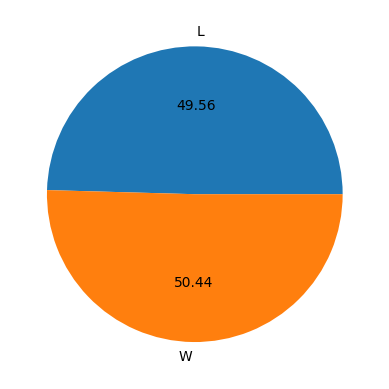

In [78]:
from matplotlib import pyplot as plt

count_wins = shot_logs.groupby(shot_logs.W.name).count().loc[:, shot_logs.GAME_ID.name].values
values = shot_logs.groupby(shot_logs.W.name).count().index.values
attribute_name = np.array([])

for i in range(values.size):
  attribute_name = np.append(attribute_name, "W" if values[i] == 1 else "L")

plt.pie(count_wins, labels=attribute_name, autopct='%.2f')
plt.show()

Prikaz stupčastog dijagrama koji prati vezu broja poena u jednoj utakmici i broja igrača koji su ostvarili taj broj poena. Isto tako, imamo prikaz stupčastog dijagrama koji prati vezu između broja driblanja u jednoj utakmici i broja igrača koji su ostvarili taj broj driblanja.

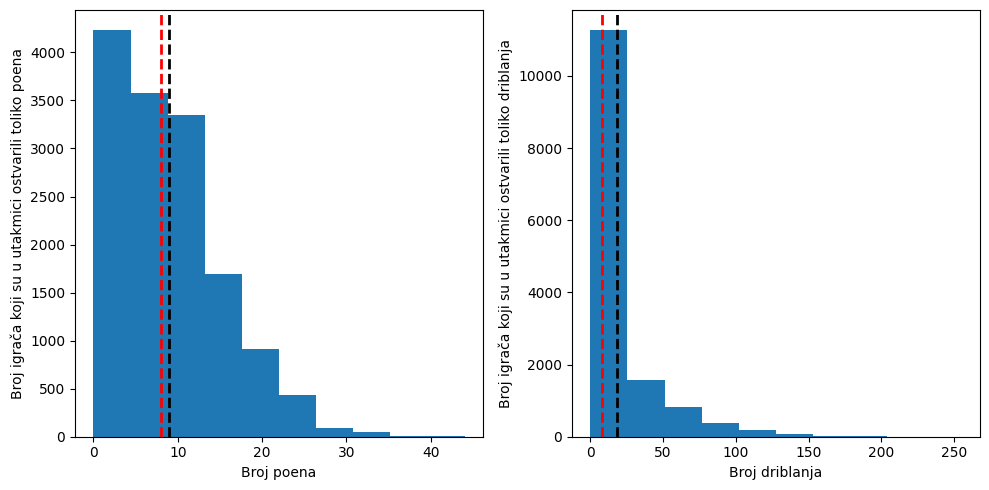

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set(xlabel="Broj poena", ylabel="Broj igrača koji su u utakmici ostvarili toliko poena")
ax[0].axvline(player.PTS.mean(), color='k', linestyle='dashed', linewidth=2)
ax[0].axvline(player.PTS.median(), color='red', linestyle='dashed', linewidth=2)
ax[0].hist(player.PTS)

ax[1].set(xlabel="Broj driblanja", ylabel="Broj igrača koji su u utakmici ostvarili toliko driblanja")
ax[1].axvline(player.dribbles_total_pg.mean(), color='k', linestyle='dashed', linewidth=2)
ax[1].axvline(player.dribbles_total_pg.median(), color='red', linestyle='dashed', linewidth=2)
ax[1].hist(player.dribbles_total_pg)

fig.tight_layout()

Prikaz prosječnog broja poena po utakmici za prvih 30 igrača s najviše poena po utkamici.

<Axes: title={'center': 'PPG'}, xlabel='Igrač', ylabel='Broj poena po utakmici'>

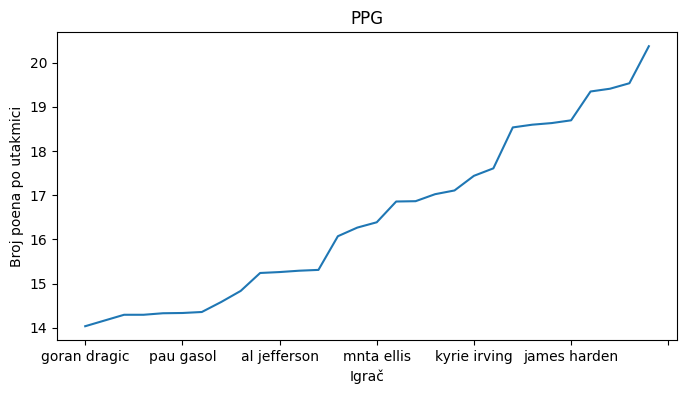

In [80]:
player_info.head(30).sort_values(by="ppg", ascending=True)[player_info.ppg.name].plot(kind='line', figsize=(8, 4), title='PPG', xlabel="Igrač", ylabel="Broj poena po utakmici")

Uočavamo skoro savršenu linearnu ovisnost vremena dodira lopte i driblanja lopte što kasnije može stvarat probleme kod korištenja određenih metoda strojnog učenja za predviđanje rezultata određenog šuta NBA igrača.

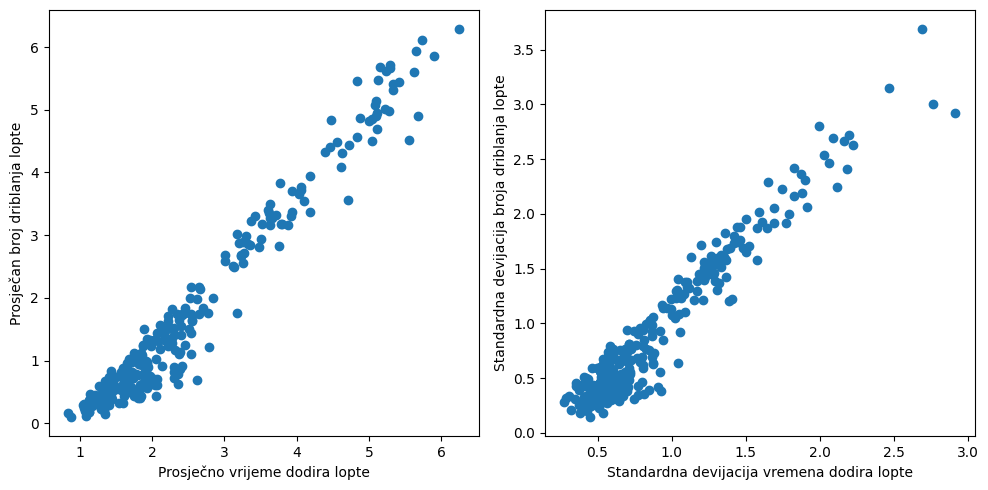

In [81]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].set(xlabel="Prosječno vrijeme dodira lopte", ylabel="Prosječan broj driblanja lopte")
ax[0].scatter(player_info.touch_time_mean, player_info.dribbles_mean)

ax[1].set(xlabel="Standardna devijacija vremena dodira lopte", ylabel="Standardna devijacija broja driblanja lopte")
ax[1].scatter(player_info.touch_time_stdev, player_info.dribbles_stdev)

fig.tight_layout()

Atribute GAME_ID, MATCHUP, CLOSEST_DEFENDER, CLOSEST_DEFENDER_PLAYER_ID, player_name i player_id trebali bismo kasnije izbacit jer su to kategoričke varijable.

In [82]:
shot_logs.drop(("GAME_ID"), axis=1, inplace=True)
shot_logs.drop(("MATCHUP"), axis=1, inplace=True)
shot_logs.drop(("CLOSEST_DEFENDER"), axis=1, inplace=True)
shot_logs.drop(("CLOSEST_DEFENDER_PLAYER_ID"), axis=1, inplace=True)
shot_logs.drop(("player_name"), axis=1, inplace=True)
shot_logs.drop(("player_id"), axis=1, inplace=True)

Uočavamo kako nemamo monotonih atributa, tj. atributa čija vrijednost jednoliko raste, ali uočavamo multikolinearne atribute kao što su SHOT_RESULT, FGM i PTS.
Brišemo PTS i FGM.

In [83]:
shot_logs.drop(("PTS"), axis=1, inplace=True)
shot_logs.drop(("FGM"), axis=1, inplace=True)

#2. faza: Replikacija rezultata
---

### ***Podijela skupa podataka***

Podijela skupa podataka na skup za učenje i skup za ispitivanje.

In [107]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(shot_logs.drop(shot_logs.SHOT_RESULT.name, axis=1), shot_logs[shot_logs.SHOT_RESULT.name], test_size=0.05)

***Sada prvo provodimo normalizaciiju i skaliranje podataka pa prvovodimo postupak učenja.***

In [108]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import normalize
shot_logs_normalized = pd.DataFrame(normalize(shot_logs.drop([shot_logs.LOCATION.name, shot_logs.PERIOD.name, shot_logs.GAME_CLOCK.name, shot_logs.SHOT_CLOCK.name, shot_logs.PTS_TYPE.name, shot_logs.W.name, shot_logs.SHOT_RESULT.name], axis=1).to_numpy()), columns=shot_logs.drop([shot_logs.LOCATION.name, shot_logs.PERIOD.name, shot_logs.GAME_CLOCK.name, shot_logs.SHOT_CLOCK.name, shot_logs.PTS_TYPE.name, shot_logs.W.name, shot_logs.SHOT_RESULT.name], axis=1).columns)
shot_logs_normalized = pd.DataFrame(StandardScaler().fit_transform(shot_logs_normalized.to_numpy()), columns=shot_logs_normalized.columns)
shot_logs_normalized[shot_logs.LOCATION.name] = shot_logs.LOCATION.tolist()
shot_logs_normalized[shot_logs.PTS_TYPE.name] = shot_logs.PTS_TYPE.tolist()
shot_logs_normalized[shot_logs.PERIOD.name] = shot_logs.PERIOD.tolist()
shot_logs_normalized[shot_logs.GAME_CLOCK.name] = shot_logs.GAME_CLOCK.tolist()
shot_logs_normalized[shot_logs.SHOT_CLOCK.name] = shot_logs.SHOT_CLOCK.tolist()
shot_logs_normalized[shot_logs.W.name] = shot_logs.W.tolist()
shot_logs_normalized[shot_logs.SHOT_RESULT.name] = shot_logs.SHOT_RESULT.tolist()

Podijela skupa normaliziranih i skaliranih podataka na skup za učenje i skup za ispitivanje.

In [109]:
from sklearn.model_selection import train_test_split
X_train_normalized, X_test_normalized, y_train_normalized, y_test_normalized = train_test_split(shot_logs_normalized.drop(shot_logs_normalized.SHOT_RESULT.name, axis=1), shot_logs_normalized[shot_logs_normalized.SHOT_RESULT.name], test_size=0.05)

### ***Logistička regresija***

**Korišćenje logističke regresije za predviđanje rezultata šuta.**




In [110]:
from sklearn.linear_model import LogisticRegression
clf_logistic = LogisticRegression(max_iter=1000, C=10000).fit(X_train,y_train)
predictions = clf_logistic.predict(X_test)


Evaluacija modela logističke regresije.



In [111]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.58      0.45      0.50      2949
           1       0.60      0.72      0.66      3439

    accuracy                           0.59      6388
   macro avg       0.59      0.58      0.58      6388
weighted avg       0.59      0.59      0.59      6388

------------------------------------------------
Broj istinitno negativnih primjera:  1322
Broj istinitno pozitivnih primjera:  2474
Broj lažno negativnih primjera:  965
Broj lažno pozitivnih primjera:  1627
------------------------------------------------
Točnost modela je:  0.5942391984971822


***AUC/ROC krivulja***

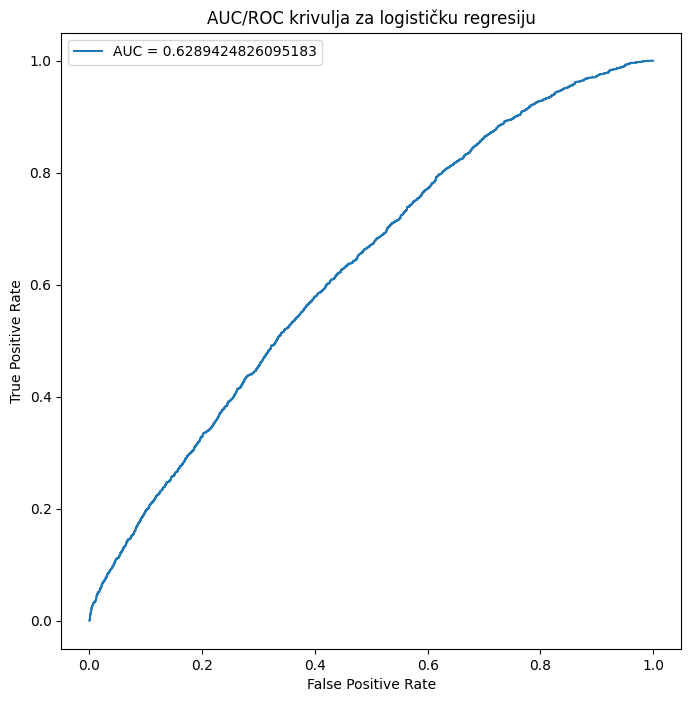

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_logistic.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za logističku regresiju")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

**Korišćenje logističke regresije za predviđanje rezultata šuta na normaliziranim i skaliranim podacima.**

In [113]:
from sklearn.linear_model import LogisticRegression
clf_logistic_normalized = LogisticRegression(max_iter=1000, C=10000).fit(X_train_normalized, y_train_normalized)
predictions_normalized = clf_logistic_normalized.predict(X_test_normalized)

Evaluacija modela logističke regresije na normaliziranim i skaliranim podacima:.

In [114]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

              precision    recall  f1-score   support

           0       0.62      0.42      0.50      2999
           1       0.60      0.77      0.68      3389

    accuracy                           0.61      6388
   macro avg       0.61      0.60      0.59      6388
weighted avg       0.61      0.61      0.60      6388

------------------------------------------------
Broj istinitno negativnih primjera:  1274
Broj istinitno pozitivnih primjera:  2613
Broj lažno negativnih primjera:  776
Broj lažno pozitivnih primjera:  1725
------------------------------------------------
Točnost modela je:  0.6084846587351284


***AUC/ROC krivulja***

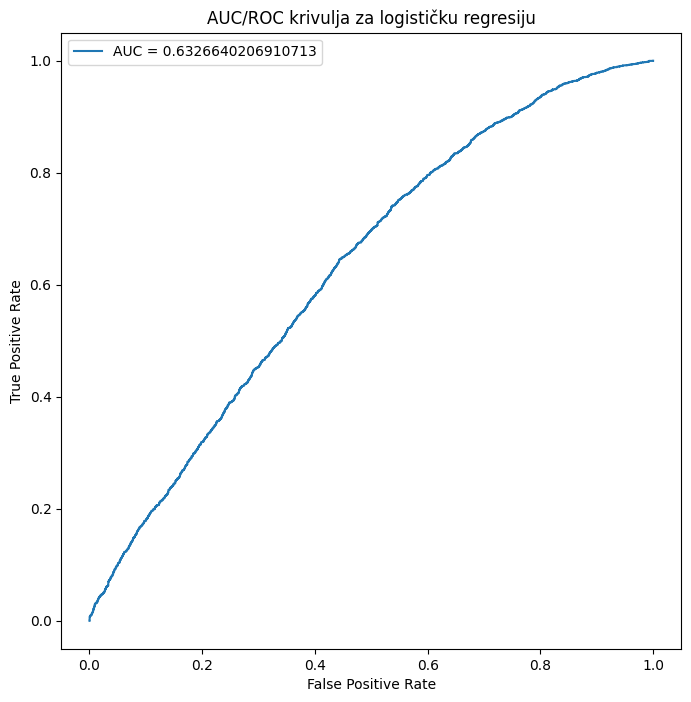

In [115]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_logistic_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za logističku regresiju")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Stroj potpornih vektora***

***Korišćenje ugrađene metode za učenje modela stroja potpornih vektora***

In [116]:
from sklearn.svm import SVC
clf_svm = SVC().fit(X_train, y_train)
predictions = clf_svm.predict(X_test)

Evaluacija modela stroja potpornog vektora.

In [117]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

              precision    recall  f1-score   support

           0       0.56      0.48      0.52      2949
           1       0.60      0.68      0.64      3439

    accuracy                           0.59      6388
   macro avg       0.58      0.58      0.58      6388
weighted avg       0.59      0.59      0.58      6388

------------------------------------------------
Broj istinitno negativnih primjera:  1418
Broj istinitno pozitivnih primjera:  2337
Broj lažno negativnih primjera:  1102
Broj lažno pozitivnih primjera:  1531
------------------------------------------------
Točnost modela je:  0.5878209142141515


***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_svm.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za SVM")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađene metode za učenje modela stroja potpornih vektora na normaliziranim i skaliranim podacima.***

In [ ]:
from sklearn.svm import SVC
clf_svm_normalized = SVC().fit(X_train_normalized, y_train_normalized)
predictions_normalized = clf_svm_normalized.predict(X_test_normalized)

Evaluacija modela stroja potpornog vektora na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_svm_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za SVM")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Neuronske mreže sa sigmoidnom aktivacijskom funkcijom za skriveni i izlazni sloj neurona***

***Korišćenje ugrađenih metoda za definiciju i učenje neuronske mreže.***

In [ ]:
from sklearn.neural_network import MLPClassifier
clf_neural = MLPClassifier(hidden_layer_sizes=(50,), activation="logistic").fit(X_train, y_train)
predictions = clf_neural.predict(X_test)

Evaluacija neuronske mreže.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_neural.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za sigmoidnu neuronsku mrežu")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađenih metoda za definiciju i učenje neuronske mreže na normaliziranim i skaliranim podacima.***

In [ ]:
from sklearn.neural_network import MLPClassifier
clf_neural_normalized = MLPClassifier(hidden_layer_sizes=(50,), activation="logistic").fit(X_train_normalized, y_train_normalized)
predictions_normalized = clf_neural_normalized.predict(X_test_normalized)

Evaluacija neuronskih mreže na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_neural_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za sigmoidnu neuronsku mrežu")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Neuronske mreže sa RELU aktivacijskom funkcijom za skriveni i sigmoidnu aktivacijsku funkciju za izlazni sloj neurona***

***Korišćenje ugrađenih metoda za definiciju i učenje neuronske mreže.***

In [ ]:
from sklearn.neural_network import MLPClassifier
clf_neural = MLPClassifier(hidden_layer_sizes=(50,), activation="relu").fit(X_train, y_train)
predictions = clf_neural.predict(X_test)

Evaluacija neuronske mreže.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_neural.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za ReLU neuronsku mrežu")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađenih metoda za definiciju i učenje neuronske mreže na normaliziranim i skaliranim podacima.***

In [ ]:
from sklearn.neural_network import MLPClassifier
clf_neural_normalized = MLPClassifier(hidden_layer_sizes=(50,), activation="relu").fit(X_train_normalized, y_train_normalized)
predictions_normalized = clf_neural_normalized.predict(X_test_normalized)

Evaluacija neuronskih mreže na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_neural_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za ReLU neuronsku mrežu")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Naivni Bayesov klasifikator***

***Korišćenje ugrađene metode za učenje modela Naivnog Bayesovog klasifikatora.***

In [ ]:
from sklearn.naive_bayes import GaussianNB
clf_gnb = GaussianNB().fit(X_train, y_train)
predictions = clf_gnb.predict(X_test)

Evaluacija Naivnog Bayesovog klasifikatora.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_gnb.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za naivnog Bayesovog klasifikatora")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađene metode za učenje modela Naivnog Bayesovog klasifikatora na normaliziranim i skaliranim podacima.***

In [ ]:
from sklearn.naive_bayes import GaussianNB
clf_gnb_normalized = GaussianNB().fit(X_train_normalized, y_train_normalized)
predictions_normalized = clf_gnb_normalized.predict(X_test_normalized)

Evaluacija Naivnog Bayesovog klasifikatora na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = clf_gnb_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za naivnog Bayesovog klasifikatora")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Klasifikator slučajnih šuma***

***Korišćenje ugrađene metode za učenje modela klasifikatora slučajnih šuma.***

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_classifier = RandomForestClassifier(
    n_estimators=80,
    min_samples_leaf=50,
    bootstrap=True).fit(X_train, y_train)
predictions = random_forest_classifier.predict(X_test)

Evaluacija modela klasifikatora slučajnih šuma.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = random_forest_classifier.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za slučajne šume")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađene metode za učenje modela klasifikatora slučajnih šuma na normaliziranim i skaliranim podacima.***

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest_classifier_normalized = RandomForestClassifier(
    n_estimators=80,
    min_samples_leaf=50,
    bootstrap=True).fit(X_train_normalized, y_train_normalized)
predictions_normalized = random_forest_classifier_normalized.predict(X_test_normalized)

Evaluacija modela klasifikatora slučajnih šuma na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = random_forest_classifier_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za slučajne šume")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

### ***Gradient boosting algoritam***

***Korišćenje ugrađene metode za učenje modela algoritmom gradient boosting.***



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier = GradientBoostingClassifier(
    n_estimators=1,
    learning_rate=0.0001,
    max_depth=3,
    min_weight_fraction_leaf=0.0001).fit(X_train, y_train)
predictions = gradient_boosting_classifier.predict(X_test)

Evaluacija modela klasifikatora naučenog algoritmom gradient boosting.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test, predictions))

conf_matrix = confusion_matrix(y_test, predictions)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test, predictions))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = gradient_boosting_classifier.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za gradient boosting")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

***Korišćenje ugrađene metode za učenje modela algoritmom gradient boosting na normaliziranim i skaliranim podacima.***


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_classifier_normalized = GradientBoostingClassifier(
    n_estimators=1,
    learning_rate=0.0001,
    max_depth=3,
    min_weight_fraction_leaf=0.0001).fit(X_train_normalized, y_train_normalized)
predictions_normalized = gradient_boosting_classifier_normalized.predict(X_test_normalized)

Evaluacija modela klasifikatora naučenog algoritmom gradient boosting na normaliziranim i skaliranim podacima.

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(classification_report(y_test_normalized, predictions_normalized))

conf_matrix = confusion_matrix(y_test_normalized, predictions_normalized)

print("------------------------------------------------")
print("Broj istinitno negativnih primjera: ", conf_matrix[0][0])
print("Broj istinitno pozitivnih primjera: ", conf_matrix[1][1])

print("Broj lažno negativnih primjera: ", conf_matrix[1][0])
print("Broj lažno pozitivnih primjera: ", conf_matrix[0][1])

print("------------------------------------------------")
print("Točnost modela je: ", accuracy_score(y_test_normalized, predictions_normalized))

***AUC/ROC krivulja***

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

prob = gradient_boosting_classifier_normalized.predict_proba(X_test_normalized)
fpr, tpr, thresholds = roc_curve(y_test_normalized, prob[:, 1])
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, label="AUC = " + str(auc(fpr, tpr)))
plt.title("AUC/ROC krivulja za gradient boosting")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()